In [29]:
import pygad
import numpy as np
import string
import matplotlib.pyplot as plt
import random

# GA Using PYGAD

In [30]:
# Target and Encoding
TARGET = "ARTIFICIAL INTELLIGENCE"
ALPHABET = list(string.ascii_uppercase) + [" "]

char_to_int = {c: i for i, c in enumerate(ALPHABET)}
int_to_char = {i: c for i, c in enumerate(ALPHABET)}
NUM_GENES = len(TARGET)
GENE_SPACE = list(range(len(ALPHABET)))

best_history = []
avg_history = []

In [31]:
# Fitness Function
def fitness_func(ga_instance, solution, solution_idx):
    decoded = "".join(int_to_char[int(g)] for g in solution)    
    return sum(decoded[i] == TARGET[i] for i in range(NUM_GENES))
def on_generation(ga_instance):    
    f = ga_instance.last_generation_fitness    
    best_history.append(np.max(f))   
    avg_history.append(np.mean(f))

In [32]:
ga = pygad.GA(    
              num_generations=1000,    
              sol_per_pop=100,    
              num_parents_mating=20,    
              num_genes=NUM_GENES,    
              gene_space=GENE_SPACE,          
              fitness_func=fitness_func,    
              parent_selection_type="sss",    
              keep_parents=10,    
              crossover_type="single_point",    
              mutation_type="random",    
              mutation_probability=0.01,    
              on_generation=on_generation)

In [33]:
ga.run()
solution, fitness, _ = ga.best_solution()
decoded_solution = "".join(int_to_char[int(g)] for g in solution)

print("Best Solution:", decoded_solution)
print("Fitness:", fitness)

Best Solution: ARTIFICIAL INTELLIGENCE
Fitness: 23


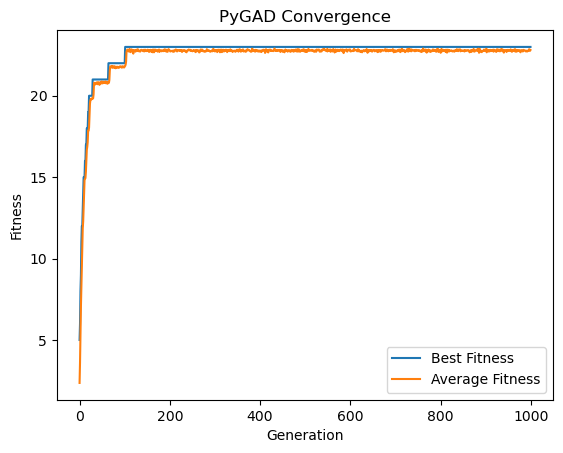

In [34]:
plt.figure()
plt.plot(best_history, label="Best Fitness")
plt.plot(avg_history, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("PyGAD Convergence")
plt.legend()
plt.show()

# Mutation Effect

In [35]:
def run_with_mutation(m_rate):    
    history = []
    def on_gen(ga):        
        history.append(np.max(ga.last_generation_fitness))
    ga_test = pygad.GA(        
                       num_generations=500,        
                       sol_per_pop=100,        
                       num_parents_mating=20,        
                       num_genes=len(TARGET),        
                       gene_space=GENE_SPACE,        
                       fitness_func=fitness_func,        
                       parent_selection_type="sss",        
                       keep_parents=10,        
                       crossover_type="single_point",        
                       mutation_type="random",        
                       mutation_probability=m_rate,        
                       on_generation=on_gen    )    
    ga_test.run()    
    return history

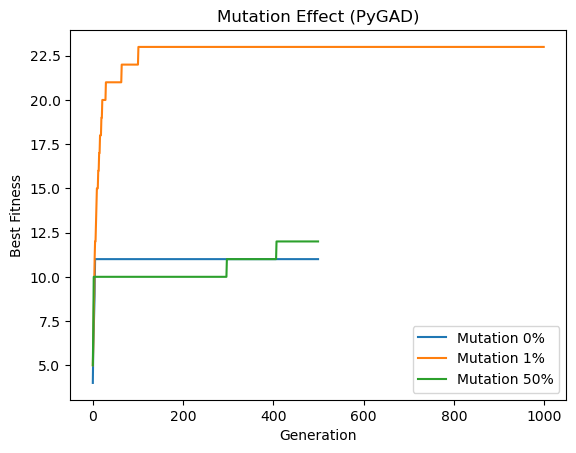

In [36]:
best_0 = run_with_mutation(0)
best_50 = run_with_mutation(0.5)
plt.figure()
plt.plot(best_0, label="Mutation 0%")
plt.plot(best_history, label="Mutation 1%")
plt.plot(best_50, label="Mutation 50%")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Mutation Effect (PyGAD)")
plt.legend()
plt.show()

# GA Without PYGAD

In [37]:
# Target and Genes
TARGET = "ARTIFICIAL INTELLIGENCE"
POP_SIZE = 100
ELITE_SIZE = 10
MAX_GEN = 1000
GENES = string.ascii_uppercase + " "
BITS_PER_CHAR = 5   

In [38]:
# Gray Encoding
def binary_to_gray(n):
    return n ^ (n >> 1)

def gray_to_binary(g):
    b = g
    while g > 0:
        g >>= 1
        b ^= g
    return b

def int_to_bits(n, bits):
    return format(n, f'0{bits}b')

def bits_to_int(bits):
    return int(bits, 2)
def encode_gray(text):
    encoded = ""
    for ch in text:
        idx = GENES.index(ch)
        gray = binary_to_gray(idx)
        encoded += int_to_bits(gray, BITS_PER_CHAR)
    return encoded

def decode_gray(bitstring):
    decoded = ""
    for i in range(0, len(bitstring), BITS_PER_CHAR):
        bits = bitstring[i:i + BITS_PER_CHAR]
        gray = bits_to_int(bits)
        binary = gray_to_binary(gray)
        binary %= len(GENES)
        decoded += GENES[binary]
    return decoded

In [39]:
def random_individual():
    text = "".join(random.choice(GENES) for _ in range(len(TARGET)))
    return encode_gray(text)

def fitness(individual):
    decoded = decode_gray(individual)
    return sum(decoded[i] == TARGET[i] for i in range(len(TARGET)))

def crossover(p1, p2):
    point = random.randint(1, len(p1) - 1)
    return p1[:point] + p2[point:]

def mutate(individual, mutation_rate):
    bits = list(individual)
    for i in range(len(bits)):
        if random.random() < mutation_rate:
            bits[i] = '1' if bits[i] == '0' else '0'
    return "".join(bits)


In [40]:
def run_ga(mutation_rate):

    population = [random_individual() for _ in range(POP_SIZE)]
    best_history = []
    avg_history = []

    for generation in range(MAX_GEN):

        fitness_values = [fitness(ind) for ind in population]

        population = [
            ind for _, ind in sorted(
                zip(fitness_values, population),
                reverse=True
            )
        ]

        best_history.append(fitness(population[0]))
        avg_history.append(sum(fitness_values) / POP_SIZE)

        if decode_gray(population[0]) == TARGET:
            print(f"Target found at generation {generation}")
            break

        next_generation = population[:ELITE_SIZE]

        while len(next_generation) < POP_SIZE:
            parent1 = random.choice(population[:50])
            parent2 = random.choice(population[:50])
            child = crossover(parent1, parent2)
            child = mutate(child, mutation_rate)
            next_generation.append(child)

        population = next_generation

    return best_history, avg_history


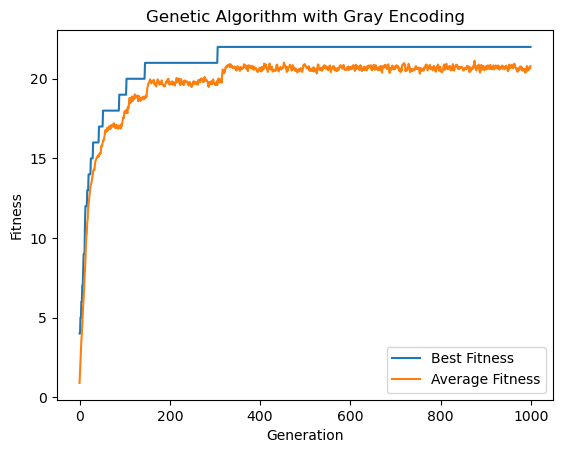

In [41]:
best, avg = run_ga(0.01)

plt.figure()
plt.plot(best, label="Best Fitness")
plt.plot(avg, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm with Gray Encoding")
plt.legend()
plt.show()

# Mutation Effect

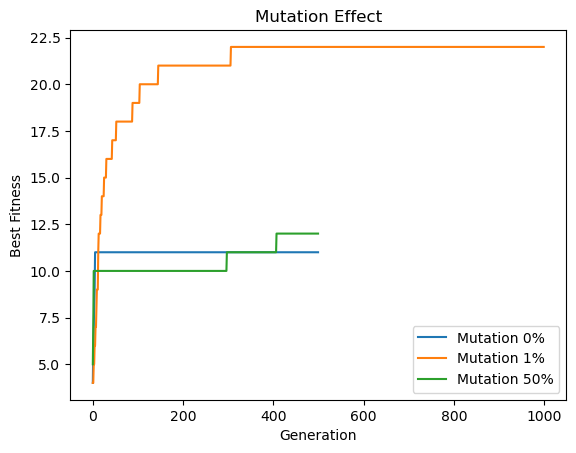

In [42]:
best0 =  run_ga(0)
best5 =  run_ga(0.5)
plt.figure()
plt.plot(best_0, label="Mutation 0%")
plt.plot(best, label="Mutation 1%")
plt.plot(best_50, label="Mutation 50%")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Mutation Effect")
plt.legend()
plt.show()